# CodSoft ML Internship — Task 1: Movie Genre Classification

**Goal:** predict a movie's genre from its plot summary / description.

**Dataset:** [Genre Classification Dataset IMDb](https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb) (Kaggle)

**Approach:**
1. Load & explore the data
2. Clean the plot text
3. Vectorize with TF-IDF
4. Train & compare Naive Bayes, Logistic Regression, and Linear SVM
5. Evaluate on a held-out validation split + the official test set
6. Save the best model


In [2]:
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the data

The dataset uses a `:::` delimiter: `ID ::: TITLE ::: GENRE ::: DESCRIPTION` for train, and `ID ::: TITLE ::: DESCRIPTION` for the unlabeled test file.

In [3]:
def load_train_data(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(" ::: ")
            if len(parts) == 4:
                _id, title, genre, description = parts
                rows.append({"title": title, "genre": genre.strip(), "description": description})
    return pd.DataFrame(rows)

def load_test_data(path, has_genre=False):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(" ::: ")
            if has_genre and len(parts) == 4:
                _id, title, genre, description = parts
                rows.append({"title": title, "genre": genre.strip(), "description": description})
            elif not has_genre and len(parts) == 3:
                _id, title, description = parts
                rows.append({"id": _id, "title": title, "description": description})
    return pd.DataFrame(rows)

train_df = load_train_data("data/train_data.txt")
print("Train shape:", train_df.shape)
train_df.head()

Train shape: (54214, 3)


,title,genre,description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


## 3. Exploratory Data Analysis

In [4]:
print("Number of unique genres:", train_df["genre"].nunique())
train_df["genre"].value_counts()

Number of unique genres: 27


genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64

C:\Users\Radhika\AppData\Local\Temp\ipykernel_24912\4139756826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="genre", data=train_df, order=order, palette="viridis")


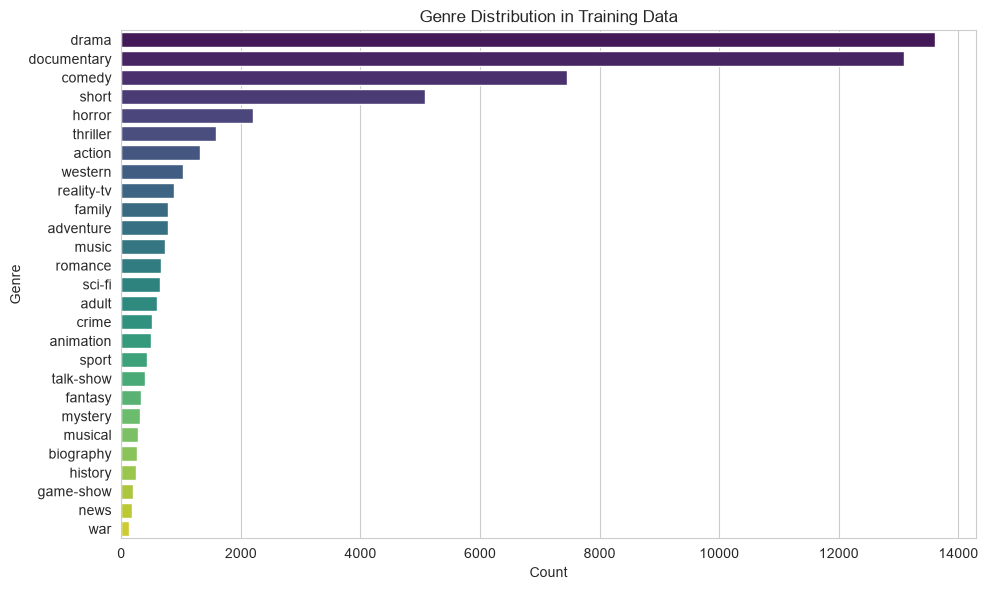

In [5]:
plt.figure(figsize=(10, 6))
order = train_df["genre"].value_counts().index
sns.countplot(y="genre", data=train_df, order=order, palette="viridis")
plt.title("Genre Distribution in Training Data")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

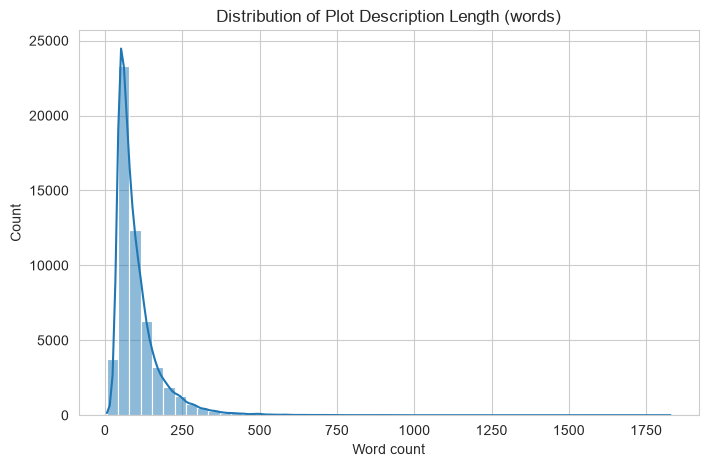

count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: description_len, dtype: float64


In [6]:
train_df["description_len"] = train_df["description"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(train_df["description_len"], bins=50, kde=True)
plt.title("Distribution of Plot Description Length (words)")
plt.xlabel("Word count")
plt.show()

print(train_df["description_len"].describe())

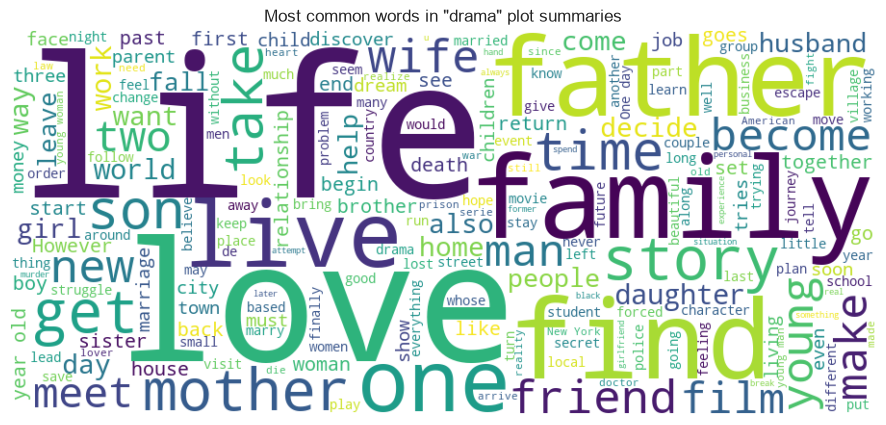

In [7]:
# Word cloud for the most common genre, just to eyeball common vocabulary
top_genre = train_df["genre"].value_counts().idxmax()
text_blob = " ".join(train_df[train_df["genre"] == top_genre]["description"].sample(
    min(2000, (train_df["genre"] == top_genre).sum()), random_state=42
))

wc = WordCloud(width=900, height=400, background_color="white", stopwords=STOPWORDS).generate(text_blob)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f'Most common words in "{top_genre}" plot summaries')
plt.show()

## 4. Text Cleaning

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

train_df["clean_description"] = train_df["description"].apply(clean_text)
train_df[["description", "clean_description"]].head()

,description,clean_description
0,Listening in to a conversation between his doc...,listening conversation doctor parents year old...
1,A brother and sister with a past incestuous re...,brother sister past incestuous relationship cu...
2,As the bus empties the students for their fiel...,bus empties students field trip museum natural...
3,To help their unemployed father make ends meet...,help unemployed father make ends meet edith tw...
4,The film's title refers not only to the un-rec...,film title refers recovered bodies ground zero...


## 5. Train / Validation Split + TF-IDF Vectorization

In [9]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    train_df["clean_description"], train_df["genre"],
    test_size=0.2, random_state=42, stratify=train_df["genre"]
)

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

print("TF-IDF matrix shape (train):", X_train.shape)

TF-IDF matrix shape (train): (43371, 20000)


## 6. Train & Compare Models

In [10]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "Linear SVM": LinearSVC(),
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    predictions[name] = preds
    print(f"  Validation accuracy: {acc:.4f}\n")

Training Naive Bayes...
  Validation accuracy: 0.4994

Training Logistic Regression...
  Validation accuracy: 0.5888

Training Linear SVM...
  Validation accuracy: 0.5759



In [11]:
for name in models:
    print(f"=== {name} ===")
    print(classification_report(y_val, predictions[name], zero_division=0))
    print("-" * 60)

=== Naive Bayes ===
              precision    recall  f1-score   support

      action       1.00      0.00      0.01       263
       adult       0.50      0.01      0.02       118
   adventure       0.60      0.02      0.04       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.54      0.37      0.44      1490
       crime       0.00      0.00      0.00       101
 documentary       0.55      0.91      0.69      2619
       drama       0.43      0.85      0.57      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       0.00      0.00      0.00        39
     history       0.00      0.00      0.00        49
      horror       0.83      0.16      0.26       441
       music       1.00      0.01      0.03       146
     musical       0.00      0.00      0.00        55
     mystery       0.00      0.00      0.00        64
       

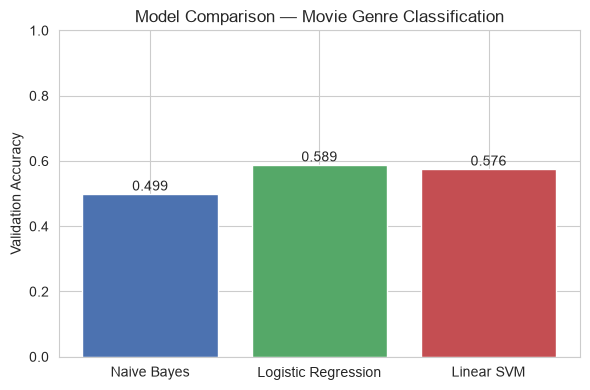

Best model: Logistic Regression (0.5888 validation accuracy)


In [12]:
plt.figure(figsize=(6, 4))
plt.bar(results.keys(), results.values(), color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison — Movie Genre Classification")
plt.ylim(0, 1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"Best model: {best_name} ({results[best_name]:.4f} validation accuracy)")

## 7. Confusion Matrix (Best Model)

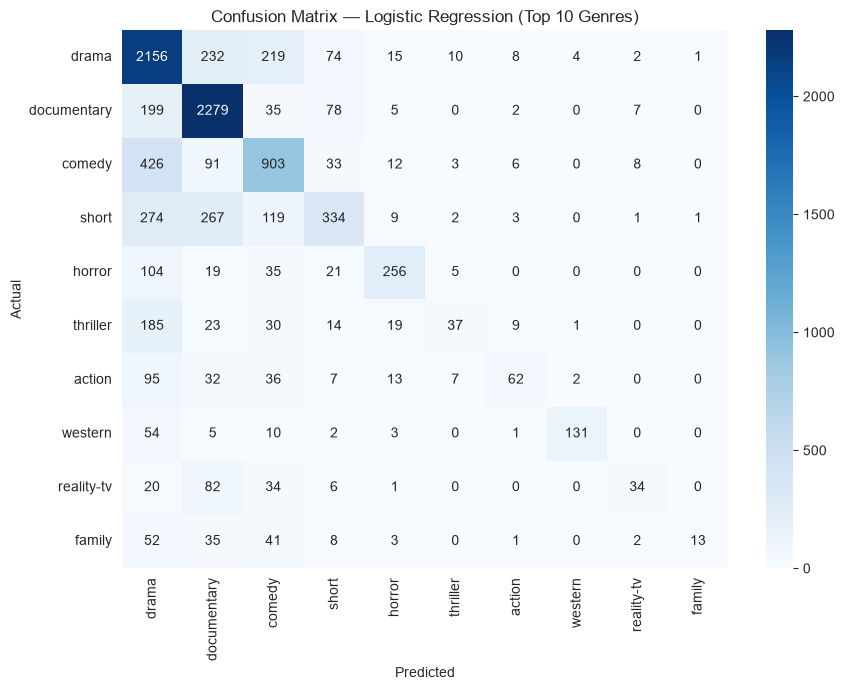

In [13]:
top_genres = train_df["genre"].value_counts().head(10).index.tolist()
mask = y_val.isin(top_genres)

cm = confusion_matrix(y_val[mask], pd.Series(predictions[best_name], index=y_val.index)[mask], labels=top_genres)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=top_genres, yticklabels=top_genres)
plt.title(f"Confusion Matrix — {best_name} (Top 10 Genres)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Evaluate on the Official Test Set

In [14]:
try:
    test_df = load_test_data("data/test_data_solution.txt", has_genre=True)
    test_df["clean_description"] = test_df["description"].apply(clean_text)
    X_test = vectorizer.transform(test_df["clean_description"])

    test_preds = best_model.predict(X_test)
    test_acc = accuracy_score(test_df["genre"], test_preds)
    print(f"Final test set accuracy ({best_name}): {test_acc:.4f}")
    print(classification_report(test_df["genre"], test_preds, zero_division=0))
except FileNotFoundError:
    print("test_data_solution.txt not found in data/ — skipping final evaluation.")

Final test set accuracy (Logistic Regression): 0.5909
              precision    recall  f1-score   support

      action       0.55      0.26      0.35      1314
       adult       0.66      0.20      0.31       590
   adventure       0.72      0.15      0.24       775
   animation       0.57      0.03      0.06       498
   biography       0.00      0.00      0.00       264
      comedy       0.53      0.60      0.56      7446
       crime       0.57      0.02      0.03       505
 documentary       0.67      0.87      0.76     13096
       drama       0.54      0.80      0.64     13612
      family       0.57      0.06      0.11       783
     fantasy       1.00      0.01      0.02       322
   game-show       0.92      0.50      0.65       193
     history       0.00      0.00      0.00       243
      horror       0.68      0.56      0.61      2204
       music       0.69      0.40      0.51       731
     musical       0.00      0.00      0.00       276
     mystery       1.00    

## 9. Try It Yourself

In [15]:
def predict_genre(plot_summary, model=best_model, vec=vectorizer):
    cleaned = clean_text(plot_summary)
    vec_input = vec.transform([cleaned])
    return model.predict(vec_input)[0]

sample_plot = "A young wizard discovers his magical heritage and battles a dark lord threatening the wizarding world."
print("Predicted genre:", predict_genre(sample_plot))

Predicted genre: fantasy


## 10. Save the Model

In [16]:
joblib.dump(best_model, "movie_genre_model.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
print("Saved model and vectorizer to disk.")

Saved model and vectorizer to disk.


## Summary

- Trained Naive Bayes, Logistic Regression, and Linear SVM on TF-IDF features from plot summaries
- Compared validation accuracy and per-class F1 (genre distribution is imbalanced — drama/documentary dominate, so minority genres score lower)
- Best model evaluated on the official held-out test set
- Model + vectorizer saved for reuse (`movie_genre_model.joblib`, `tfidf_vectorizer.joblib`)
